# imports.py

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision import transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# dataset.py

In [3]:
dataset = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
)

# idx = random.randint(0, len(dataset)-1)
# image, label = dataset[idx]

# plt.imshow(image.squeeze(), cmap="gray")
# plt.title(f"Label: {label}")
# plt.axis("off")
# plt.show()

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


# forward_diffusion.py

## Idea:

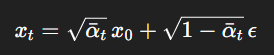

In [4]:
T = 1000
noise_scheduler = torch.linspace(10**-4, 0.02, T)

alpha = (1-noise_scheduler).to(device)
alpha_bar = torch.cumprod(alpha, dim=0).to(device)

def forward_diffusion(x0, t, alpha_bar):
    noise = torch.randn_like(x0)
    sqrt_alpha_bar = torch.sqrt(alpha_bar[t][:, None, None, None])
    sqrt_one_minus = torch.sqrt(1-alpha_bar[t][:, None, None, None])
    xt = sqrt_alpha_bar * x0 + sqrt_one_minus * noise

    return xt, noise

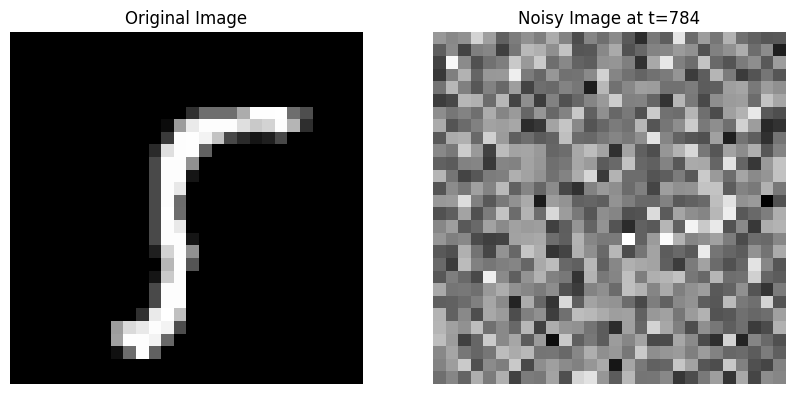

In [5]:
idx = random.randint(0, len(dataset) - 1)
example_image, _ = dataset[idx]
time_step = random.randint(0, T-1)

example_image_batch = example_image.unsqueeze(0).to(device)
time_step_batch = torch.tensor([time_step], device=device)

noisy_image_example, noise_example = forward_diffusion(example_image_batch, time_step_batch, alpha_bar)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(example_image.squeeze(), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_image_example.squeeze().cpu().numpy(), cmap='gray')
plt.title(f'Noisy Image at t={time_step}')
plt.axis('off')
plt.show()

In [6]:
alpha_bar[0]

tensor(0.9999, device='cuda:0')

# u_net.py

In [8]:
class ConditionalUNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, 128)
        self.time_embed = nn.Sequential(
            nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 128)
        )
        self.time_proj1 = nn.Linear(128, 32)
        self.time_proj2 = nn.Linear(128, 64)
        self.time_proj3 = nn.Linear(128, 128)

        # Encoder
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.enc3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)

        # Bottleneck
        self.bottleneck = nn.Conv2d(128, 128, 3, padding=1)

        # Decoder
        self.dec1 = nn.Conv2d(128+64, 64, 3, padding=1)
        self.dec2 = nn.Conv2d(64+32, 32, 3, padding=1)
        self.dec3 = nn.Conv2d(32, 1, 3, padding=1)

    def get_time_embedding(self, t, dim=128):
        half = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.time_embed(emb)

    def forward(self, x, t, label):
        temb = self.get_time_embedding(t) + self.label_embed(label)

        enc1 = F.relu(self.enc1(x))
        enc1 = enc1 + self.time_proj1(temb)[:, :, None, None]

        enc2 = F.relu(self.enc2(enc1))
        enc2 = enc2 + self.time_proj2(temb)[:, :, None, None]

        enc3 = F.relu(self.enc3(enc2))
        enc3 = enc3 + self.time_proj3(temb)[:, :, None, None]

        b = F.relu(self.bottleneck(enc3))

        dec1 = F.interpolate(b, scale_factor=2)
        dec1 = F.relu(self.dec1(torch.cat([dec1, enc2], dim=1)))

        dec2 = F.interpolate(dec1, scale_factor=2)
        dec2 = F.relu(self.dec2(torch.cat([dec2, enc1], dim=1)))

        return self.dec3(dec2)

    def fit(self, dataloader, alpha_bar, T, epochs=1):
        self.train()
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        self.to(device)

        for epoch in range(epochs):
            epoch_loss = 0.0
            for i, (x, label) in enumerate(dataloader):
                x, label = x.to(device), label.to(device)  # ← label used now
                t = torch.randint(0, T, (x.size(0),), device=device)

                xt, noise = forward_diffusion(x, t, alpha_bar)
                pred_noise = self(xt, t, label)  # ← pass label

                loss = F.mse_loss(pred_noise, noise)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                if (i+1) % 100 == 0:
                    print(f"Epoch [{epoch+1}/{epochs}], Batch [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")

            avg_loss = epoch_loss / len(dataloader)
            print(f"Epoch [{epoch+1}/{epochs}] completed. Average Loss: {avg_loss:.4f}")


# dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
Unet = torch.load('entire_model.pth', weights_only=False)
Unet.eval()
# Unet.fit(dataloader, alpha_bar, T, epochs=67)
# torch.save(Unet, 'entire_model.pth')

ConditionalUNet(
  (label_embed): Embedding(10, 128)
  (time_embed): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (time_proj1): Linear(in_features=128, out_features=32, bias=True)
  (time_proj2): Linear(in_features=128, out_features=64, bias=True)
  (time_proj3): Linear(in_features=128, out_features=128, bias=True)
  (enc1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bottleneck): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec1): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

# reverse_diffusion.py

# Idea:

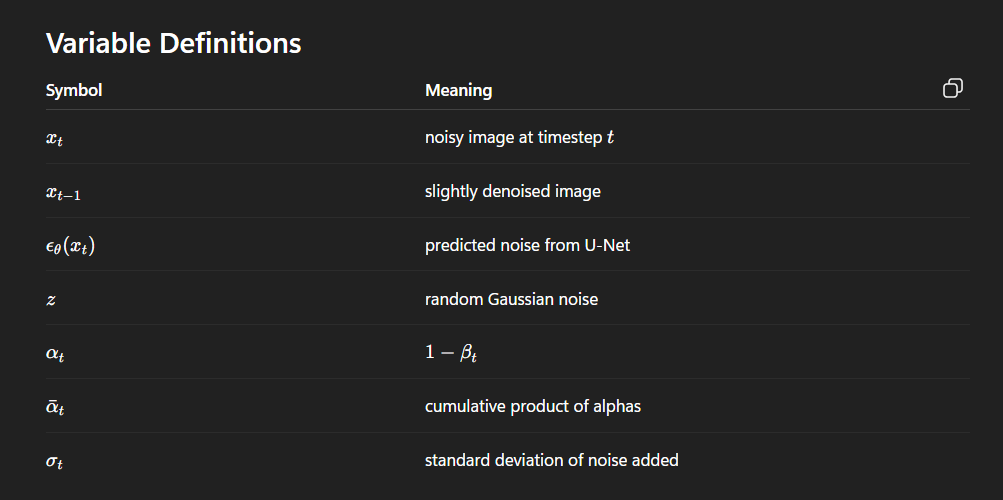

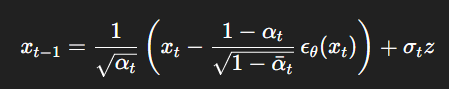

In [9]:
def reverse_diffusion(xt, t, label, alpha, alpha_bar):
    eps_theta = Unet(xt, t, label)

    sqrt_alpha_bar_t = torch.sqrt(alpha_bar[t])[:, None, None, None]
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar[t])[:, None, None, None]
    x0_pred = (xt - sqrt_one_minus_alpha_bar_t * eps_theta) / sqrt_alpha_bar_t

    beta_t = 1 - alpha[t]
    alpha_t = alpha[t]
    alpha_bar_t = alpha_bar[t]
    alpha_bar_t_prev = alpha_bar[t-1] if t > 0 else torch.tensor(1.0, device=xt.device)

    coef_x0 = torch.sqrt(alpha_bar_t_prev) * beta_t / (1 - alpha_bar_t)
    coef_xt = torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev) / (1 - alpha_bar_t)

    mu_t = coef_x0 * x0_pred + coef_xt * xt
    sigma_t = torch.sqrt(beta_t * (1-alpha_bar_t_prev) / (1-alpha_bar_t))[:, None, None, None]

    z = torch.randn_like(xt)
    xt_prev = mu_t + sigma_t * z

    return xt_prev

## generation.py

Generating digit: 9


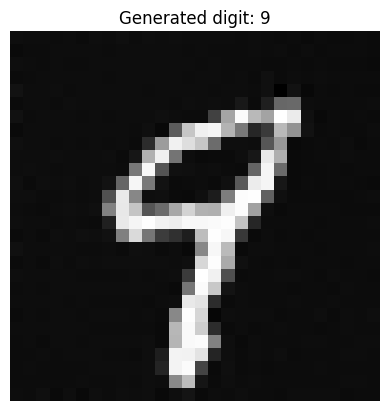

In [10]:
def generate_digit(digit):
    if digit not in range(10):
        print("Please enter a digit between 0 and 9.")
        return

    print(f"Generating digit: {digit}")
    Unet.eval()
    x = torch.randn(1, 1, 28, 28, device=device)
    label = torch.tensor([digit], device=device)

    with torch.no_grad():
        for t_val in range(T-1, -1, -1):
            t_batch = torch.tensor([t_val], device=device)
            x = reverse_diffusion(x, t_batch, label, alpha, alpha_bar)

    plt.imshow(x.squeeze().cpu().numpy(), cmap='gray')
    plt.title(f'Generated digit: {digit}')
    plt.axis('off')
    plt.show()

generate_digit(9)

# tests.py

In [ ]:
import random
import matplotlib.pyplot as plt
import torch

# Ensure Unet is in evaluation mode for sampling
Unet.eval()

# --- Forward Diffusion to get the maximally noisy image ---
image, label = dataset[random.randint(0, len(dataset)-1)]

# T is now consistently 784
max_noise_time_step = T - 1

# Prepare image and time for forward_diffusion
image_batch = image.unsqueeze(0).to(device)
t_batch_fwd = torch.tensor([max_noise_time_step], device=device)

# Perform forward diffusion to get the most noisy image
current_x_for_sampling = torch.randn(1, 1, 28, 28, device=device)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze().cpu().numpy(), cmap='gray')
plt.title(f'Original Image (Label: {label})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_image_max.squeeze().cpu().numpy(), cmap='gray')
plt.title(f'Noisy Image at t={max_noise_time_step}')
plt.axis('off')
plt.show()

print(f"\nStarting reverse diffusion from t={max_noise_time_step} down to t=0.")

# List to store (image, t_value) for step-by-step visualization
sampled_data_for_plot = []
display_interval = max_noise_time_step // 9

with torch.no_grad():
    current_x_for_sampling = noisy_image_max.clone().detach()

    # Iterate from max_noise_time_step down to 0
    for t_val in range(max_noise_time_step, -1, -1):

        # Store images at specified intervals, including t=max_noise_time_step and t=0
        if t_val == max_noise_time_step or t_val % display_interval == 0 or t_val == 0:
            sampled_data_for_plot.append((current_x_for_sampling.squeeze().cpu().clone().numpy(), t_val))

        if t_val > 0: # Only perform reverse diffusion if t > 0
            t_batch_rev = torch.tensor([t_val], device=device)
            current_x_for_sampling = reverse_diffusion(current_x_for_sampling, t_batch_rev, alpha, alpha_bar)

# Plot the collected images in a grid
num_cols = 5
num_rows = (len(sampled_data_for_plot) + num_cols - 1) // num_cols
plt.figure(figsize=(num_cols * 3, num_rows * 3))

# Plot in the order they were sampled (highest t to lowest t)
for i, (img, t_val) in enumerate(sampled_data_for_plot):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f't={t_val}')
    plt.axis('off')
plt.suptitle(f'Reverse Diffusion Process (Original Label: {label})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()